<a href="https://colab.research.google.com/github/Aryankpoor/resnet-healthcare-model/blob/master/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

root = "/content/drive/MyDrive/iucxr"

print("Contents of iucxr:")
print(os.listdir(root))

Contents of iucxr:
['indiana_projections.csv', 'indiana_reports.csv', 'images']


In [4]:
import pandas as pd
import os

projections_path = os.path.join(root, "indiana_projections.csv")
reports_path = os.path.join(root, "indiana_reports.csv")

projections = pd.read_csv(projections_path)
reports = pd.read_csv(reports_path)

print("PROJECTIONS")
print("Shape:", projections.shape)
print("\nColumns:")
print(projections.columns.tolist())

print("\n" + "="*60 + "\n")

print("REPORTS")
print("Shape:", reports.shape)
print("\nColumns:")
print(reports.columns.tolist())

PROJECTIONS
Shape: (7466, 3)

Columns:
['uid', 'filename', 'projection']


REPORTS
Shape: (3851, 8)

Columns:
['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']


In [5]:
print("===== UNIQUE IDENTIFIERS =====")

print("Projection records:", len(projections))
print("Unique projection UIDs:", projections["uid"].nunique())

print("Report records:", len(reports))
print("Unique report UIDs:", reports["uid"].nunique())

print("\nUIDs appearing in both datasets:",
      len(set(projections["uid"]) & set(reports["uid"])))

===== UNIQUE IDENTIFIERS =====
Projection records: 7466
Unique projection UIDs: 3851
Report records: 3851
Unique report UIDs: 3851

UIDs appearing in both datasets: 3851


In [6]:
reports_per_uid = reports.groupby("uid").size()

print("Reports per UID:")
print(reports_per_uid.value_counts().sort_index())

print("\nAverage reports per UID:", reports_per_uid.mean())
print("Maximum reports for one UID:", reports_per_uid.max())

Reports per UID:
1    3851
Name: count, dtype: int64

Average reports per UID: 1.0
Maximum reports for one UID: 1


In [7]:
projection_uids = set(projections["uid"])
report_uids = set(reports["uid"])

matched_uids = projection_uids & report_uids

print("Projection UIDs:", len(projection_uids))
print("Report UIDs:", len(report_uids))
print("Matched UIDs:", len(matched_uids))

print(
    "Percentage of projection UIDs with reports:",
    round(len(matched_uids) / len(projection_uids) * 100, 2),
    "%"
)

Projection UIDs: 3851
Report UIDs: 3851
Matched UIDs: 3851
Percentage of projection UIDs with reports: 100.0 %


In [8]:
projection_only = projection_uids - report_uids
report_only = report_uids - projection_uids

print("Projection UIDs without reports:", len(projection_only))
print("Report UIDs without images:", len(report_only))

Projection UIDs without reports: 0
Report UIDs without images: 0


In [9]:
print("===== PROBLEMS =====")

problem_counts = reports["Problems"].value_counts(dropna=False)

print("Unique Problems entries:", reports["Problems"].nunique())

display(problem_counts.head(30))

===== PROBLEMS =====
Unique Problems entries: 1432


,count
Problems,
normal,1379
No Indexing,92
Lung,86
Calcified Granuloma,84
Thoracic Vertebrae,59
Spine,41
Calcinosis,39
Opacity,35
Cardiomegaly,29


In [10]:
print("===== MeSH =====")

mesh_counts = reports["MeSH"].value_counts(dropna=False)

print("Unique MeSH entries:", reports["MeSH"].nunique())

display(mesh_counts.head(30))

===== MeSH =====
Unique MeSH entries: 1900


,count
MeSH,
normal,1379
No Indexing,92
Lung/hypoinflation,44
Thoracic Vertebrae/degenerative/mild,29
Thoracic Vertebrae/degenerative,23
Spine/degenerative,19
Spine/degenerative/mild,18
Cardiomegaly/mild,17
Spondylosis/thoracic vertebrae,17


In [11]:
text_columns = [
    "indication",
    "comparison",
    "findings",
    "impression"
]

for col in text_columns:
    reports[col + "_length"] = (
        reports[col]
        .fillna("")
        .astype(str)
        .str.len()
    )

display(
    reports[
        ["uid"] +
        [col + "_length" for col in text_columns]
    ].describe()
)

,uid,indication_length,comparison_length,findings_length,impression_length
count,3851.000000,3851.000000,3851.000000,3851.000000,3851.000000
mean,1998.134511,31.648143,10.484030,190.242015,76.202545
std,1158.010359,24.119078,15.582789,118.140421,82.546406
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,995.500000,13.000000,0.000000,119.500000,33.000000
50%,1991.000000,29.000000,5.000000,188.000000,39.000000
75%,3010.500000,42.000000,14.000000,255.000000,89.000000
max,3999.000000,228.000000,330.000000,1054.000000,887.000000


In [12]:
display(
    reports[
        [
            "uid",
            "MeSH",
            "Problems",
            "image",
            "indication",
            "findings",
            "impression"
        ]
    ].head(10)
)

,uid,MeSH,Problems,image,indication,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
5,6,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.
6,7,Pulmonary Atelectasis/base;Spondylosis/thoraci...,Pulmonary Atelectasis;Spondylosis;Arthritis,Xray Chest PA and Lateral,Preop lumbar surgery,The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...
7,8,normal,normal,Xray Chest PA and Lateral,XXXX-year-old with XXXX on XXXX. Dyspnea. Hist...,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.
8,9,Calcified Granuloma/lung/upper lobe/right;Dens...,Calcified Granuloma;Density,Xray Chest PA and Lateral,Chest pain today. History of stent placement 7...,The XXXX examination consists of frontal and l...,Increased size of density in the left cardioph...
9,10,Calcified Granuloma/lung/upper lobe/right,Calcified Granuloma,PA and lateral chest x-XXXX XXXX.,"XXXX-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.


In [13]:
import os

images_root = os.path.join(root, "images")

print("Contents of images folder:")
print(os.listdir(images_root))

Contents of images folder:
['images_normalized']


In [14]:
normalized_root = os.path.join(images_root, "images_normalized")

print("Image directory:", normalized_root)
print("Exists:", os.path.exists(normalized_root))

Image directory: /content/drive/MyDrive/iucxr/images/images_normalized
Exists: True


In [15]:
import os

sample_filenames = projections["filename"].sample(
    n=min(100, len(projections)),
    random_state=42
)

exists = []

for filename in sample_filenames:
    path = os.path.join(normalized_root, filename)
    exists.append(os.path.isfile(path))

print("Sample images checked:", len(exists))
print("Images found:", sum(exists))
print("Images missing:", len(exists) - sum(exists))
print("Existence rate:", round(sum(exists) / len(exists) * 100, 2), "%")

Sample images checked: 100
Images found: 100
Images missing: 0
Existence rate: 100.0 %


In [16]:
from PIL import Image
import os

sample_filenames = projections["filename"].sample(
    n=min(20, len(projections)),
    random_state=42
)

image_info = []

for filename in sample_filenames:
    path = os.path.join(normalized_root, filename)

    try:
        with Image.open(path) as img:
            image_info.append({
                "filename": filename,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })
    except Exception as e:
        image_info.append({
            "filename": filename,
            "width": None,
            "height": None,
            "mode": None,
            "format": f"ERROR: {e}"
        })

image_info_df = pd.DataFrame(image_info)

display(image_info_df)

,filename,width,height,mode,format
0,1220_IM-0148-3001.dcm.png,2496,2048,L,PNG
1,1874_IM-0565-1001.dcm.png,2048,2048,L,PNG
2,1136_IM-0092-2001.dcm.png,2048,2496,L,PNG
3,1543_IM-0353-1001.dcm.png,2496,2048,L,PNG
4,3001_IM-1387-3001.dcm.png,2496,2048,L,PNG
5,995_IM-2478-1001.dcm.png,2048,2066,L,PNG
6,2223_IM-0827-2001.dcm.png,2048,2496,L,PNG
7,2152_IM-0772-2001.dcm.png,2048,2496,L,PNG
8,3792_IM-1906-1002.dcm.png,2061,2048,L,PNG
9,2595_IM-1086-1001.dcm.png,2048,2496,L,PNG


In [17]:
print("===== IMAGE DIMENSION ANALYSIS =====")

print("\nWidth distribution:")
display(image_info_df["width"].value_counts().head(20))

print("\nHeight distribution:")
display(image_info_df["height"].value_counts().head(20))

print("\nImage modes:")
display(image_info_df["mode"].value_counts())

print("\nImage formats:")
display(image_info_df["format"].value_counts())

===== IMAGE DIMENSION ANALYSIS =====

Width distribution:


,count
width,
2048,13
2496,5
2061,1
2022,1



Height distribution:


,count
height,
2048,10
2496,7
2066,1
2791,1
2016,1



Image modes:


,count
mode,
L,20



Image formats:


,count
format,
PNG,20


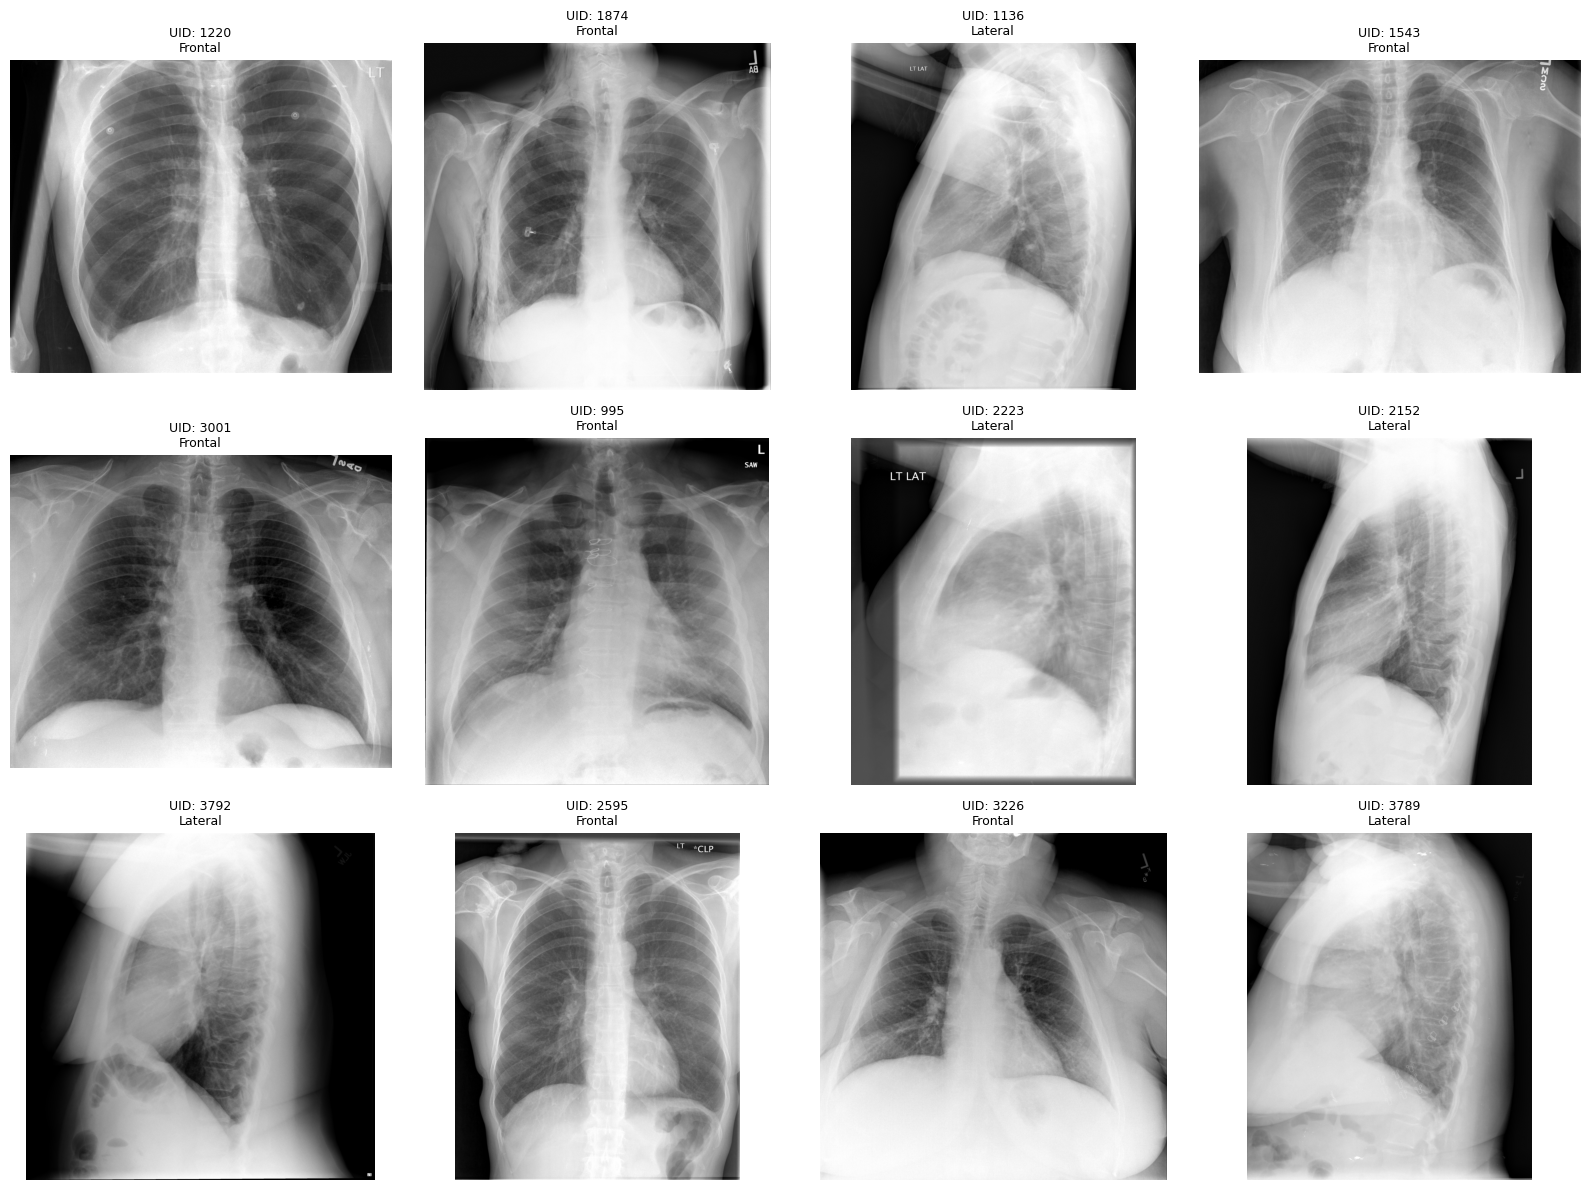

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

visual_samples = projections.sample(
    n=12,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, (_, row) in zip(axes.flat, visual_samples.iterrows()):
    path = os.path.join(normalized_root, row["filename"])

    with Image.open(path) as img:
        ax.imshow(img, cmap="gray")

    ax.set_title(
        f"UID: {row['uid']}\n{row['projection']}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print("===== PROJECTION DISTRIBUTION =====")

projection_counts = projections["projection"].value_counts()

display(projection_counts)

print("\nPercentage distribution:")
display(
    (projections["projection"].value_counts(normalize=True) * 100)
    .round(2)
)

===== PROJECTION DISTRIBUTION =====


,count
projection,
Frontal,3818
Lateral,3648



Percentage distribution:


,proportion
projection,
Frontal,51.14
Lateral,48.86


In [20]:
projection_per_uid = (
    projections
    .pivot_table(
        index="uid",
        columns="projection",
        values="filename",
        aggfunc="count",
        fill_value=0
    )
)

display(projection_per_uid.head(20))

projection,Frontal,Lateral
uid,,
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [21]:
print("===== PROJECTION COMBINATIONS =====")

projection_per_uid["combination"] = projection_per_uid.apply(
    lambda row: " + ".join(
        [col for col in projection_per_uid.columns
         if col != "combination" and row[col] > 0]
    ),
    axis=1
)

display(projection_per_uid["combination"].value_counts())

===== PROJECTION COMBINATIONS =====


,count
combination,
Frontal + Lateral,3388
Frontal,301
Lateral,162


In [22]:
from PIL import Image
import numpy as np
import os

pixel_stats = []

sample = projections.sample(
    n=min(100, len(projections)),
    random_state=42
)

for _, row in sample.iterrows():
    path = os.path.join(normalized_root, row["filename"])

    with Image.open(path) as img:
        img_array = np.asarray(img)

        pixel_stats.append({
            "uid": row["uid"],
            "filename": row["filename"],
            "projection": row["projection"],
            "width": img.width,
            "height": img.height,
            "min_pixel": img_array.min(),
            "max_pixel": img_array.max(),
            "mean_pixel": img_array.mean(),
            "std_pixel": img_array.std()
        })

pixel_stats_df = pd.DataFrame(pixel_stats)

display(pixel_stats_df.head())

,uid,filename,projection,width,height,min_pixel,max_pixel,mean_pixel,std_pixel
0,1220,1220_IM-0148-3001.dcm.png,Frontal,2496,2048,66,255,160.468929,48.829076
1,1874,1874_IM-0565-1001.dcm.png,Frontal,2048,2048,31,255,154.197678,59.954536
2,1136,1136_IM-0092-2001.dcm.png,Lateral,2048,2496,5,255,158.470252,72.977017
3,1543,1543_IM-0353-1001.dcm.png,Frontal,2496,2048,11,255,162.335335,59.171532
4,3001,3001_IM-1387-3001.dcm.png,Frontal,2496,2048,80,255,170.490762,42.711771


In [23]:
print("===== PIXEL STATISTICS =====")

display(
    pixel_stats_df[
        [
            "min_pixel",
            "max_pixel",
            "mean_pixel",
            "std_pixel"
        ]
    ].describe()
)

===== PIXEL STATISTICS =====


,min_pixel,max_pixel,mean_pixel,std_pixel
count,100.000000,100.0,100.000000,100.000000
mean,18.420000,255.0,152.612555,63.799860
std,21.119276,0.0,22.832480,12.926015
min,0.000000,255.0,87.782730,31.799988
25%,3.750000,255.0,139.903402,54.792114
50%,7.000000,255.0,156.613790,63.791536
75%,31.000000,255.0,170.426426,73.328478
max,87.000000,255.0,209.290653,89.234516


In [24]:
print("===== POTENTIALLY BLANK IMAGES =====")

blank_like = pixel_stats_df[
    (pixel_stats_df["max_pixel"] == 0) |
    (pixel_stats_df["std_pixel"] < 1)
]

print("Potentially blank/near-blank images:", len(blank_like))

display(blank_like)

===== POTENTIALLY BLANK IMAGES =====
Potentially blank/near-blank images: 0


,uid,filename,projection,width,height,min_pixel,max_pixel,mean_pixel,std_pixel


In [25]:
import re
from collections import Counter

def extract_labels(series):
    labels = []

    for value in series.dropna():
        value = str(value).strip()

        if value.lower() in ["normal", "nan", "no indexing", ""]:
            continue

        # Split compound entries
        parts = value.split(";")

        for part in parts:
            part = part.strip()

            if part:
                labels.append(part)

    return Counter(labels)


problem_labels = extract_labels(reports["Problems"])

print("===== INDIVIDUAL PROBLEM LABELS =====")
print("Total unique labels:", len(problem_labels))

problem_label_df = pd.DataFrame(
    problem_labels.most_common(),
    columns=["label", "count"]
)

display(problem_label_df.head(50))

===== INDIVIDUAL PROBLEM LABELS =====
Total unique labels: 119


,label,count
0,Lung,553
1,Opacity,509
2,Cardiomegaly,345
3,Calcinosis,332
4,Pulmonary Atelectasis,330
5,Calcified Granuloma,276
6,Thoracic Vertebrae,256
7,Cicatrix,196
8,Spine,174
9,Markings,167


In [26]:
mesh_labels = extract_labels(reports["MeSH"])

print("===== INDIVIDUAL MeSH LABELS =====")
print("Total unique labels:", len(mesh_labels))

mesh_label_df = pd.DataFrame(
    mesh_labels.most_common(),
    columns=["label", "count"]
)

display(mesh_label_df.head(50))

===== INDIVIDUAL MeSH LABELS =====
Total unique labels: 1679


,label,count
0,Lung/hypoinflation,238
1,Lung/hyperdistention,159
2,Cardiomegaly,139
3,Cardiomegaly/mild,129
4,Aorta/tortuous,118
5,Thoracic Vertebrae/degenerative,114
6,Spine/degenerative,109
7,Granulomatous Disease,93
8,Atherosclerosis/aorta,92
9,Thoracic Vertebrae/degenerative/mild,91


In [27]:
cardio_problem_entries = (
    reports["Problems"]
    .dropna()
    .astype(str)
)

cardio_problem_entries = cardio_problem_entries[
    cardio_problem_entries.str.contains(
        "Cardiomegaly",
        case=False,
        na=False
    )
]

print("Reports containing Cardiomegaly in Problems:",
      len(cardio_problem_entries))

display(
    cardio_problem_entries.value_counts().to_frame("count")
)

Reports containing Cardiomegaly in Problems: 345


,count
Problems,
Cardiomegaly,29
Cardiomegaly;Aorta,9
Cardiomegaly;Calcinosis,7
Cardiomegaly;Lung,6
Cardiomegaly;Opacity;Pulmonary Edema,4
...,...
Calcinosis;Calcinosis;Cardiomegaly,1
"Diaphragm;Pulmonary Atelectasis;Pulmonary Atelectasis;Cardiomegaly;Atherosclerosis;Heart;Kyphosis;Bone Diseases, Metabolic;Deformity;Thoracic Vertebrae",1
Cardiomegaly;Aorta;Opacity;Scoliosis;Osteophyte;Spondylosis,1


In [28]:
candidate_findings = [
    "Cardiomegaly",
    "Opacity",
    "Pulmonary Atelectasis",
    "Pleural Effusion",
    "Calcified Granuloma",
    "Nodule",
    "Emphysema",
    "Pneumonia",
    "Consolidation"
]

for finding in candidate_findings:
    mask = reports["Problems"].fillna("").str.contains(
        finding,
        case=False,
        na=False
    )

    print(f"{finding}: {mask.sum()} UIDs")

Cardiomegaly: 345 UIDs
Opacity: 432 UIDs
Pulmonary Atelectasis: 315 UIDs
Pleural Effusion: 149 UIDs
Calcified Granuloma: 266 UIDs
Nodule: 106 UIDs
Emphysema: 103 UIDs
Pneumonia: 40 UIDs
Consolidation: 30 UIDs


In [29]:
candidate_stats = []

for finding in candidate_findings:
    mask = reports["Problems"].fillna("").str.contains(
        finding,
        case=False,
        na=False
    )

    positive = mask.sum()
    negative = len(reports) - positive

    candidate_stats.append({
        "Finding": finding,
        "Positive UIDs": positive,
        "Negative UIDs": negative,
        "Positive %": round(positive / len(reports) * 100, 2)
    })

candidate_stats_df = pd.DataFrame(candidate_stats)

display(candidate_stats_df.sort_values(
    "Positive UIDs",
    ascending=False
))

,Finding,Positive UIDs,Negative UIDs,Positive %
1,Opacity,432,3419,11.22
0,Cardiomegaly,345,3506,8.96
2,Pulmonary Atelectasis,315,3536,8.18
4,Calcified Granuloma,266,3585,6.91
3,Pleural Effusion,149,3702,3.87
5,Nodule,106,3745,2.75
6,Emphysema,103,3748,2.67
7,Pneumonia,40,3811,1.04
8,Consolidation,30,3821,0.78


In [30]:
normal_mask = (
    reports["Problems"]
    .fillna("")
    .str.strip()
    .str.lower()
    == "normal"
)

print("Explicitly normal reports:", normal_mask.sum())
print(
    "Percentage:",
    round(normal_mask.mean() * 100, 2),
    "%"
)

Explicitly normal reports: 1379
Percentage: 35.81 %


In [31]:
display(
    reports.loc[
        normal_mask,
        ["uid", "Problems", "MeSH", "findings", "impression"]
    ].head(10)
)

,uid,Problems,MeSH,findings,impression
0,1,normal,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,3,normal,normal,NaN,"No displaced rib fractures, pneumothorax, or p..."
5,6,normal,normal,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.
7,8,normal,normal,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.
10,11,normal,normal,Cardiomediastinal silhouette and pulmonary vas...,No acute cardiopulmonary findings.
11,12,normal,normal,Lungs are clear bilaterally. Cardiac and media...,No acute cardiopulmonary abnormality.
15,16,normal,normal,NaN,NaN
16,17,normal,normal,No focal areas of consolidation. No suspicious...,No acute cardiopulmonary abnormality.
19,20,normal,normal,The cardiac and mediastinal silhouettes are un...,No evidence of acute cardiopulmonary process. ...
21,22,normal,normal,"The lungs are clear, and without focal air spa...",No acute cardiopulmonary abnormality.


In [32]:
cardio_mask = reports["Problems"].fillna("").str.contains(
    "Cardiomegaly",
    case=False,
    na=False
)

cardio_reports = reports.loc[
    cardio_mask,
    [
        "uid",
        "Problems",
        "MeSH",
        "findings",
        "impression"
    ]
].copy()

print("Cardiomegaly-positive studies:", len(cardio_reports))

display(cardio_reports.head(20))

Cardiomegaly-positive studies: 345


,uid,Problems,MeSH,findings,impression
1,2,Cardiomegaly;Pulmonary Artery,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
28,29,"Cardiomegaly;Diaphragm;Tube, Inserted;Airspace...",Cardiomegaly/borderline;Diaphragm/left/elevate...,NaN,Borderline heart size. Elevated left diaphragm...
44,45,Cardiomegaly;Pulmonary Congestion,Cardiomegaly;Pulmonary Congestion,Stable cardiomegaly with vascular prominence w...,Stable cardiomegaly without overt pulmonary ed...
49,50,Cardiomegaly;Spine;Lung,Cardiomegaly;Spine/degenerative;Lung/hypoinfla...,A XXXX XXXX lung volumes. Lungs are clear with...,Cardiomegaly with low lung volumes which are g...
87,88,Cardiomegaly;Markings;Spine;Heart Failure,Cardiomegaly/mild;Markings/lung/interstitial/d...,Heart is mildly heart enlarged. Mediastinal co...,1. Findings consistent with mild congestive he...
100,101,Cardiomegaly;Technical Quality of Image Unsati...,Cardiomegaly/mild;Technical Quality of Image U...,The heart is again mildly enlarged. Mediastina...,1. Mild stable cardiomegaly and central vascul...
121,123,Cardiomegaly;Aorta;Density;Opacity,Cardiomegaly/mild;Aorta/tortuous;Density/lung/...,Mild cardiomegaly. Tortuous aorta. No focal in...,Asymmetric right medial apical opacity which m...
137,139,"Cardiac Shadow;Opacity;Aorta, Thoracic;Calcino...",Cardiac Shadow/enlarged/mild;Opacity/supracard...,The cardiac silhouette is mildly enlarged. A l...,1. Lobulated anterior mediastinal opacity on t...
148,152,"Cardiomegaly;Aorta;Deformity;Fractures, Bone",Cardiomegaly/mild;Aorta/tortuous;Deformity/rib...,Stable cardiomediastinal silhouette with mild ...,No acute findings.
170,175,Cardiomegaly;Aorta;Diaphragm;Pulmonary Atelect...,Cardiomegaly/mild;Aorta/tortuous;Diaphragm/rig...,Mild cardiomegaly unchanged. Stable superior m...,Minimal XXXX left base atelectasis/infiltrate....


In [33]:
cardio_mesh = cardio_reports["MeSH"].fillna("").str.contains(
    "Cardiomegaly",
    case=False,
    na=False
)

print("Cardiomegaly in Problems:", len(cardio_reports))
print("Also present in MeSH:", cardio_mesh.sum())

print(
    "Agreement:",
    round(cardio_mesh.mean() * 100, 2),
    "%"
)

Cardiomegaly in Problems: 345
Also present in MeSH: 345
Agreement: 100.0 %


In [34]:
display(
    cardio_reports[
        [
            "uid",
            "Problems",
            "MeSH",
            "findings",
            "impression"
        ]
    ].head(30)
)

,uid,Problems,MeSH,findings,impression
1,2,Cardiomegaly;Pulmonary Artery,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
28,29,"Cardiomegaly;Diaphragm;Tube, Inserted;Airspace...",Cardiomegaly/borderline;Diaphragm/left/elevate...,NaN,Borderline heart size. Elevated left diaphragm...
44,45,Cardiomegaly;Pulmonary Congestion,Cardiomegaly;Pulmonary Congestion,Stable cardiomegaly with vascular prominence w...,Stable cardiomegaly without overt pulmonary ed...
49,50,Cardiomegaly;Spine;Lung,Cardiomegaly;Spine/degenerative;Lung/hypoinfla...,A XXXX XXXX lung volumes. Lungs are clear with...,Cardiomegaly with low lung volumes which are g...
87,88,Cardiomegaly;Markings;Spine;Heart Failure,Cardiomegaly/mild;Markings/lung/interstitial/d...,Heart is mildly heart enlarged. Mediastinal co...,1. Findings consistent with mild congestive he...
100,101,Cardiomegaly;Technical Quality of Image Unsati...,Cardiomegaly/mild;Technical Quality of Image U...,The heart is again mildly enlarged. Mediastina...,1. Mild stable cardiomegaly and central vascul...
121,123,Cardiomegaly;Aorta;Density;Opacity,Cardiomegaly/mild;Aorta/tortuous;Density/lung/...,Mild cardiomegaly. Tortuous aorta. No focal in...,Asymmetric right medial apical opacity which m...
137,139,"Cardiac Shadow;Opacity;Aorta, Thoracic;Calcino...",Cardiac Shadow/enlarged/mild;Opacity/supracard...,The cardiac silhouette is mildly enlarged. A l...,1. Lobulated anterior mediastinal opacity on t...
148,152,"Cardiomegaly;Aorta;Deformity;Fractures, Bone",Cardiomegaly/mild;Aorta/tortuous;Deformity/rib...,Stable cardiomediastinal silhouette with mild ...,No acute findings.
170,175,Cardiomegaly;Aorta;Diaphragm;Pulmonary Atelect...,Cardiomegaly/mild;Aorta/tortuous;Diaphragm/rig...,Mild cardiomegaly unchanged. Stable superior m...,Minimal XXXX left base atelectasis/infiltrate....


In [35]:
normal_reports = reports.loc[
    normal_mask,
    ["uid", "Problems", "MeSH", "findings", "impression"]
]

print("Normal studies:", len(normal_reports))

display(normal_reports.head(20))

Normal studies: 1379


,uid,Problems,MeSH,findings,impression
0,1,normal,normal,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,3,normal,normal,NaN,"No displaced rib fractures, pneumothorax, or p..."
5,6,normal,normal,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.
7,8,normal,normal,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.
10,11,normal,normal,Cardiomediastinal silhouette and pulmonary vas...,No acute cardiopulmonary findings.
11,12,normal,normal,Lungs are clear bilaterally. Cardiac and media...,No acute cardiopulmonary abnormality.
15,16,normal,normal,NaN,NaN
16,17,normal,normal,No focal areas of consolidation. No suspicious...,No acute cardiopulmonary abnormality.
19,20,normal,normal,The cardiac and mediastinal silhouettes are un...,No evidence of acute cardiopulmonary process. ...
21,22,normal,normal,"The lungs are clear, and without focal air spa...",No acute cardiopulmonary abnormality.


In [36]:
print("Cardiomegaly-positive:", cardio_mask.sum())
print("Explicitly normal:", normal_mask.sum())
print("Overlap:", (cardio_mask & normal_mask).sum())

Cardiomegaly-positive: 345
Explicitly normal: 1379
Overlap: 0


In [37]:
# ===== INITIAL BINARY TARGET =====

cardio_mask = reports["Problems"].fillna("").str.contains(
    "Cardiomegaly",
    case=False,
    na=False
)

normal_mask = (
    reports["Problems"]
    .fillna("")
    .str.strip()
    .str.lower()
    == "normal"
)

positive_uids = set(reports.loc[cardio_mask, "uid"])
negative_uids = set(reports.loc[normal_mask, "uid"])

print("Cardiomegaly-positive studies:", len(positive_uids))
print("Explicitly normal studies:", len(negative_uids))
print("Overlap:", len(positive_uids & negative_uids))

Cardiomegaly-positive studies: 345
Explicitly normal studies: 1379
Overlap: 0


In [38]:
# ===== CREATE FRONTAL IMAGE DATASET =====

frontal = projections[
    projections["projection"].str.lower() == "frontal"
].copy()

# Keep only studies that have a frontal image
frontal = frontal[frontal["uid"].isin(
    positive_uids | negative_uids
)].copy()

# Create target
frontal["label"] = frontal["uid"].apply(
    lambda x: 1 if x in positive_uids else 0
)

# Construct complete file path
frontal["image_path"] = frontal["filename"].apply(
    lambda x: os.path.join(normalized_root, x)
)

# Keep one frontal image per UID
frontal = frontal.drop_duplicates(subset="uid")

print("Total studies:", len(frontal))
print("\nClass distribution:")
print(frontal["label"].value_counts())

display(frontal.head())

Total studies: 1662

Class distribution:
label
0    1343
1     319
Name: count, dtype: int64


,uid,filename,projection,label,image_path
0,1,1_IM-0001-4001.dcm.png,Frontal,0,/content/drive/MyDrive/iucxr/images/images_nor...
2,2,2_IM-0652-1001.dcm.png,Frontal,1,/content/drive/MyDrive/iucxr/images/images_nor...
4,3,3_IM-1384-1001.dcm.png,Frontal,0,/content/drive/MyDrive/iucxr/images/images_nor...
10,6,6_IM-2192-1001.dcm.png,Frontal,0,/content/drive/MyDrive/iucxr/images/images_nor...
14,8,8_IM-2333-1001.dcm.png,Frontal,0,/content/drive/MyDrive/iucxr/images/images_nor...


In [39]:
print("===== MODEL DATASET CHECK =====")

print("Total studies:", len(frontal))
print("Cardiomegaly:", (frontal["label"] == 1).sum())
print("Normal:", (frontal["label"] == 0).sum())

print("\nMissing image files:")

missing = ~frontal["image_path"].apply(os.path.isfile)

print("Missing:", missing.sum())
print("Available:", (~missing).sum())

===== MODEL DATASET CHECK =====
Total studies: 1662
Cardiomegaly: 319
Normal: 1343

Missing image files:
Missing: 0
Available: 1662


In [40]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    frontal,
    test_size=0.30,
    stratify=frontal["label"],
    random_state=42
)

# Split temporary into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("===== DATASET SPLIT =====")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

===== DATASET SPLIT =====
Train: 1163
Validation: 249
Test: 250

Train labels:
label
0    940
1    223
Name: count, dtype: int64

Validation labels:
label
0    201
1     48
Name: count, dtype: int64

Test labels:
label
0    202
1     48
Name: count, dtype: int64


In [41]:
split_dir = os.path.join(root, "baseline_splits")
os.makedirs(split_dir, exist_ok=True)

train_df.to_csv(
    os.path.join(split_dir, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(split_dir, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(split_dir, "test.csv"),
    index=False
)

print("Saved dataset splits to:")
print(split_dir)
print(os.listdir(split_dir))

Saved dataset splits to:
/content/drive/MyDrive/iucxr/baseline_splits
['train.csv', 'validation.csv', 'test.csv']


In [42]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
import numpy as np

In [43]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


In [44]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [45]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = torch.tensor(
            row["label"],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [46]:
train_dataset = ChestXrayDataset(
    train_df,
    transform=image_transform
)

val_dataset = ChestXrayDataset(
    val_df,
    transform=image_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    transform=image_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 73
Validation batches: 16
Test batches: 16


In [47]:
num_positive = (train_df["label"] == 1).sum()
num_negative = (train_df["label"] == 0).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32
)

print("Positive training samples:", num_positive)
print("Negative training samples:", num_negative)
print("Positive class weight:", pos_weight.item())

Positive training samples: 223
Negative training samples: 940
Positive class weight: 4.215246677398682


In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Replace final classification layer
model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [49]:
pos_weight = pos_weight.to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer and loss initialized.")

Optimizer and loss initialized.


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, loader):

    model.eval()

    all_labels = []
    all_probs = []

    total_loss = 0.0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).squeeze(1)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    predictions = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(
            all_labels, predictions
        ),
        "precision": precision_score(
            all_labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            all_labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            all_labels,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            all_labels,
            all_probs
        )
    }

    return metrics

In [51]:
num_epochs = 5

best_val_auc = 0.0

checkpoint_dir = os.path.join(
    root,
    "baseline_checkpoints"
)

os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze(1)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    val_metrics = evaluate_model(
        model,
        val_loader
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val AUC: {val_metrics['roc_auc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

    if val_metrics["roc_auc"] > best_val_auc:

        best_val_auc = val_metrics["roc_auc"]

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc": best_val_auc
            },
            os.path.join(
                checkpoint_dir,
                "resnet18_cardiomegaly_best.pth"
            )
        )

print("\nBest validation AUC:", best_val_auc)

Epoch 1/5 | Train Loss: 0.7144 | Val Loss: 0.4597 | Val AUC: 0.9475 | Val F1: 0.7652
Epoch 2/5 | Train Loss: 0.3097 | Val Loss: 0.5506 | Val AUC: 0.9266 | Val F1: 0.7568
Epoch 3/5 | Train Loss: 0.1892 | Val Loss: 0.5002 | Val AUC: 0.9483 | Val F1: 0.7586
Epoch 4/5 | Train Loss: 0.1191 | Val Loss: 0.6285 | Val AUC: 0.9270 | Val F1: 0.7500
Epoch 5/5 | Train Loss: 0.0840 | Val Loss: 0.5857 | Val AUC: 0.9439 | Val F1: 0.7692

Best validation AUC: 0.9482794361525705


In [53]:
# ===== LOAD BEST CHECKPOINT AND EVALUATE ON TEST SET =====

best_checkpoint = os.path.join(
    checkpoint_dir,
    "resnet18_cardiomegaly_best.pth"
)

checkpoint = torch.load(
    best_checkpoint,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded best model from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation AUC:",
    checkpoint["val_auc"]
)

test_metrics = evaluate_model(
    model,
    test_loader
)

print("\n===== FIRST BASELINE TEST RESULTS =====")

for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

Loaded best model from epoch: 3
Best validation AUC: 0.9482794361525705

===== FIRST BASELINE TEST RESULTS =====
loss: 0.4948
accuracy: 0.8880
precision: 0.6613
recall: 0.8542
f1: 0.7455
roc_auc: 0.9485


Confusion Matrix:
[[181  21]
 [  7  41]]


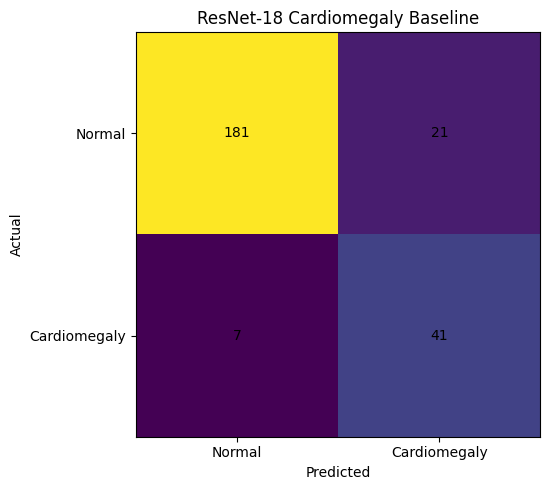

In [54]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images).squeeze(1)

        probs = torch.sigmoid(outputs)

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

predictions = (
    all_probs >= 0.5
).astype(int)

cm = confusion_matrix(
    all_labels,
    predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["Normal", "Cardiomegaly"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Cardiomegaly"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet-18 Cardiomegaly Baseline")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()